# 05 — Regional stratification (A5)
Per-basin shear effect at fixed CAPE: the slope of median 40-dBZ top vs shear within the middle CAPE quartiles, and P(MCS) response. Tests robustness / regime dependence.

In [1]:
import sys; sys.path.insert(0, '.')
from _shc import *
con = connect()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shear effect on 40-dBZ top (mid-CAPE), by region:
                 dHt_dShear_km_per_ms        n  pmcs_lo  pmcs_hi
region                                                          
Maritime Cont.                 -0.055  4765308    0.034    0.046
US Great Plains                -0.025   145991    0.034    0.067
SE S.America                   -0.013   252634    0.040    0.086
E Pacific ITCZ                 -0.012   855129    0.026    0.037
Amazon                         -0.011  1698959    0.040    0.051
W Pacific pool                 -0.005  3865870    0.018    0.042
Congo                          -0.004   771697    0.054    0.018
Sahel/W Africa                 -0.002   459934    0.052    0.072
Bay of Bengal                   0.027  1056512    0.034    0.068


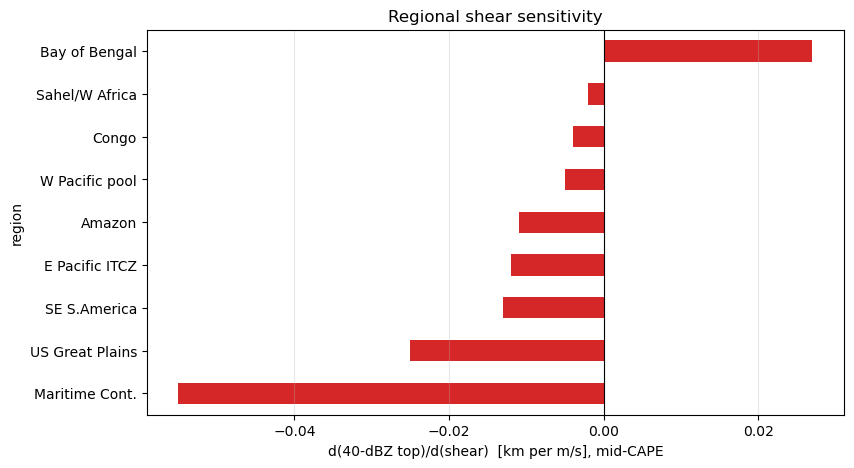

In [2]:
import numpy as np
rows=[]
for name,(la0,la1,lo0,lo1) in REGIONS.items():
    w=f'AND centroid_lat BETWEEN {la0} AND {la1} AND centroid_lon BETWEEN {lo0} AND {lo1}'
    d=q(con, f'''WITH s AS (SELECT ht40_km, {SHEAR} sh, is_mcs FROM fe
         WHERE {CONV_FILTER} AND {SHEAR}<{SHEAR_MAX} AND {AMBIENT_CAPE} BETWEEN 500 AND 3000 {w})
         SELECT floor(sh/{SHEAR_W})*{SHEAR_W} sb, quantile_cont(ht40_km,0.5) ht,
                avg(CAST(is_mcs AS DOUBLE)) pmcs, count(*) n FROM s GROUP BY 1 HAVING count(*)>={MIN_BIN_N} ORDER BY 1''')
    if len(d)>=3:
        slope=np.polyfit(d.sb, d.ht, 1)[0]      # km per (m/s)
        rows.append(dict(region=name, dHt_dShear_km_per_ms=round(slope,3),
                         n=int(d.n.sum()), pmcs_lo=round(d.pmcs.iloc[0],3), pmcs_hi=round(d.pmcs.iloc[-1],3)))
reg=pd.DataFrame(rows).set_index('region').sort_values('dHt_dShear_km_per_ms')
print('Shear effect on 40-dBZ top (mid-CAPE), by region:'); print(reg.to_string())
reg['dHt_dShear_km_per_ms'].plot.barh(figsize=(9,5), color='tab:red'); plt.axvline(0,color='k',lw=.8)
plt.xlabel('d(40-dBZ top)/d(shear)  [km per m/s], mid-CAPE'); plt.title('Regional shear sensitivity'); plt.grid(axis='x',alpha=.3); plt.show()